# 🧠 LSTM Encoder_Decoder EN→FR (From Scratch, **No torchtext**, Ready for Colab)


Notebook này không dùng `torchtext` (chỉ dùng `torch`, `spacy`, `nltk`), để tránh lỗi libtorchtext trên Colab.

## 1. Cài đặt thư viện

In [1]:
!pip install torch spacy nltk
!python -m spacy download en_core_web_sm
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 151.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 88.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Import thư viện

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

import spacy
import random, math
from collections import Counter
import matplotlib.pyplot as plt
import nltk

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


## 3. Tokenizer với spaCy (không dùng torchtext)

In [3]:
# Load spaCy models
nlp_en = spacy.load("en_core_web_sm")
nlp_fr = spacy.load("fr_core_news_sm")


def en_tokenize(text):
    doc = nlp_en(text.strip())
    return [t.text.lower() for t in doc if not t.is_space]


def fr_tokenize(text):
    doc = nlp_fr(text.strip())
    return [t.text.lower() for t in doc if not t.is_space]


# Test nhanh
print(en_tokenize("A black dog is running."))
print(fr_tokenize("Un chien noir court."))

['a', 'black', 'dog', 'is', 'running', '.']
['un', 'chien', 'noir', 'court', '.']


## 4. Tải dataset Multi30K EN–FR (các file .en/.fr)

In [4]:
import os
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
path = r"/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw"
os.listdir(path)

['test_2018_flickr.en',
 'train.fr',
 'val.en',
 'test_2017_mscoco.fr',
 'test_2017_mscoco.en',
 'test_2018_flickr.fr',
 'test_2016_flickr.fr',
 'val.fr',
 'train.en',
 'test_2016_flickr.en',
 'test_2017_flickr.fr',
 'test_2017_flickr.en']

In [ ]:
# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/train.en.gz"
# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/train.fr.gz"
# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/val.en.gz"
# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/val.fr.gz"

In [ ]:
# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/test_2016_flickr.en.gz"
# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/test_2016_flickr.fr.gz"

# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/test_2017_flickr.en.gz"
# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/test_2017_flickr.fr.gz"

# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/test_2017_mscoco.en.gz"
# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/test_2017_mscoco.fr.gz"

# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/test_2018_flickr.en.gz"
# !gzip -d "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw/test_2018_flickr.fr.gz"

In [6]:
# ===========================================================
# BƯỚC 4 — Load dataset từ Google Drive (KHÔNG dùng upload)
# ===========================================================

base = "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/task1/raw"

def load_lines(path):
    with open(path, encoding='utf8') as f:
        return [l.strip() for l in f]

# --------------------------
# TRAIN + VAL (chuẩn Multi30K)
# --------------------------
train_en = load_lines(f"{base}/train.en")
train_fr = load_lines(f"{base}/train.fr")

val_en   = load_lines(f"{base}/val.en")
val_fr   = load_lines(f"{base}/val.fr")

# --------------------------
# GỘP TẤT CẢ FILE TEST EN–FR
# --------------------------
test_files = [
    ("test_2016_flickr.en",  "test_2016_flickr.fr"),
    ("test_2017_flickr.en",  "test_2017_flickr.fr"),
    ("test_2017_mscoco.en",  "test_2017_mscoco.fr"),
    ("test_2018_flickr.en",  "test_2018_flickr.fr"),
]

test_en, test_fr = [], []

for en_file, fr_file in test_files:
    test_en += load_lines(f"{base}/{en_file}")
    test_fr += load_lines(f"{base}/{fr_file}")

# --------------------------
# Kiểm tra dữ liệu load đúng
# --------------------------
print("Train size:", len(train_en))
print("Val size:", len(val_en))
print("Test size (tổng):", len(test_en))

print("Ví dụ test EN:", test_en[0])
print("Ví dụ test FR:", test_fr[0])

Train size: 29000
Val size: 1014
Test size (tổng): 3532
Ví dụ test EN: A man in an orange hat starring at something.
Ví dụ test FR: Un homme avec un chapeau orange regardant quelque chose.


## 5. Xây vocabulary từ đầu (không dùng torchtext)

In [7]:
SPECIAL_TOKENS = ['<unk>', '<pad>', '<sos>', '<eos>']

class Vocab:
    def __init__(self, texts, tokenizer, max_size=10000, specials=SPECIAL_TOKENS):
        counter = Counter()
        for line in texts:
            counter.update(tokenizer(line))

        self.itos = list(specials)
        for tok, _ in counter.most_common(max_size - len(self.itos)):
            if tok not in self.itos:
                self.itos.append(tok)

        self.stoi = {tok: idx for idx, tok in enumerate(self.itos)}

        # Đảm bảo các token đặc biệt tồn tại
        for sp in specials:
            if sp not in self.stoi:
                self.stoi[sp] = len(self.itos)
                self.itos.append(sp)

        self.unk_index = self.stoi['<unk>']
        self.pad_index = self.stoi['<pad>']
        self.sos_index = self.stoi['<sos>']
        self.eos_index = self.stoi['<eos>']

    def __len__(self):
        return len(self.itos)

    def __getitem__(self, token):
        return self.stoi.get(token, self.unk_index)

    def lookup_token(self, idx):
        return self.itos[idx]

    def get_stoi(self):
        return self.stoi


# Xây vocab cho EN / FR từ tập train
en_vocab = Vocab(train_en, en_tokenize, max_size=10000)
fr_vocab = Vocab(train_fr, fr_tokenize, max_size=10000)

print('EN vocab size:', len(en_vocab))
print('FR vocab size:', len(fr_vocab))
print('Index <pad> EN:', en_vocab.pad_index)
print('Index <pad> FR:', fr_vocab.pad_index)

EN vocab size: 9796
FR vocab size: 10000
Index <pad> EN: 1
Index <pad> FR: 1


## 6. Chuyển câu thành tensor chỉ số (ID)

In [8]:
def sentence_to_ids_en(text):
    tokens = en_tokenize(text)
    ids = [en_vocab.sos_index] + [en_vocab[t] for t in tokens] + [en_vocab.eos_index]
    return torch.tensor(ids, dtype=torch.long)


def sentence_to_ids_fr(text):
    tokens = fr_tokenize(text)
    ids = [fr_vocab.sos_index] + [fr_vocab[t] for t in tokens] + [fr_vocab.eos_index]
    return torch.tensor(ids, dtype=torch.long)


def build_pairs(en_lines, fr_lines):
    pairs = []
    for en_line, fr_line in zip(en_lines, fr_lines):
        src_ids = sentence_to_ids_en(en_line)
        tgt_ids = sentence_to_ids_fr(fr_line)
        pairs.append((src_ids, tgt_ids))
    return pairs


train_pairs = build_pairs(train_en, train_fr)
val_pairs   = build_pairs(val_en, val_fr)
test_pairs  = build_pairs(test_en, test_fr)

print('Số cặp train:', len(train_pairs))
print('Ví dụ tensor EN:', train_pairs[0][0][:10])
print('Ví dụ tensor FR:', train_pairs[0][1][:10])

Số cặp train: 29000
Ví dụ tensor EN: tensor([  2,  16,  24,  15,  25, 774,  17,  57,  80, 202])
Ví dụ tensor FR: tensor([   2,   21,   81,   32,  214,   28,   88,   70,    7, 1170])


## 7. Collate function & DataLoader (padding + sort length + pack)

In [9]:
def collate_fn(batch):
    # batch: list[(src_tensor, tgt_tensor)]
    src_list, tgt_list = zip(*batch)

    src_lengths = [len(s) for s in src_list]
    # Sắp xếp giảm dần độ dài
    sorted_idx = sorted(range(len(src_lengths)), key=lambda i: -src_lengths[i])
    src_list = [src_list[i] for i in sorted_idx]
    tgt_list = [tgt_list[i] for i in sorted_idx]
    src_lengths = [len(s) for s in src_list]

    src_padded = pad_sequence(src_list, batch_first=True, padding_value=en_vocab.pad_index)
    tgt_padded = pad_sequence(tgt_list, batch_first=True, padding_value=fr_vocab.pad_index)

    return src_padded, torch.tensor(src_lengths, dtype=torch.long), tgt_padded


BATCH_SIZE = 64

train_loader = DataLoader(train_pairs, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_pairs,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

## 8. Xây mô hình Encoder–Decoder LSTM từ đầu

In [10]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=512, hid_dim=512, num_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=en_vocab.pad_index)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, src, src_lengths):
        # src: (B, T)
        embedded = self.embedding(src)                     # (B, T, E)
        packed = pack_padded_sequence(embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=True)
        packed_outputs, (hidden, cell) = self.lstm(packed)
        # outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=512, hid_dim=512, num_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=fr_vocab.pad_index)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_tokens, hidden, cell):
        # input_tokens: (B,)  -> ta thêm chiều time thành (B,1)
        embedded = self.embedding(input_tokens.unsqueeze(1))   # (B,1,E)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # outputs: (B,1,H)
        logits = self.fc_out(outputs.squeeze(1))               # (B,V)
        return logits, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_pad_idx = tgt_pad_idx

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.5):
        """
        src: (B, src_len)
        src_lengths: (B)
        tgt: (B, tgt_len)
        """
        batch_size, tgt_len = tgt.size()
        vocab_size = self.decoder.fc_out.out_features

        # tensor để lưu tất cả logits dự đoán
        outputs = torch.zeros(batch_size, tgt_len-1, vocab_size, device=src.device)

        hidden, cell = self.encoder(src, src_lengths)

        # token đầu tiên đưa vào decoder là <sos> của target
        input_token = tgt[:, 0]  # (B,)

        for t in range(1, tgt_len):
            logits, hidden, cell = self.decoder(input_token, hidden, cell)
            outputs[:, t-1, :] = logits

            # Chọn token tiếp theo
            top1 = logits.argmax(1)  # (B,)

            teacher_force = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if teacher_force else top1

        return outputs  # (B, tgt_len-1, V)

## 9. Khởi tạo model, hàm loss, optimizer

In [11]:
enc = Encoder(vocab_size=len(en_vocab)).to(device)
dec = Decoder(vocab_size=len(fr_vocab)).to(device)
model = Seq2Seq(enc, dec, tgt_pad_idx=fr_vocab.pad_index).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=fr_vocab.pad_index)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9796, 512, padding_idx=1)
    (lstm): LSTM(512, 512, num_layers=2, batch_first=True, dropout=0.5)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 512, padding_idx=1)
    (lstm): LSTM(512, 512, num_layers=2, batch_first=True, dropout=0.5)
    (fc_out): Linear(in_features=512, out_features=10000, bias=True)
  )
)


## 10. Huấn luyện (có early stopping + lưu best_model.pth)

In [ ]:
EPOCHS = 10
PATIENCE = 3  # early stopping nếu val_loss không giảm sau 3 epoch

best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    ######################
    # Train
    ######################
    model.train()
    total_train_loss = 0.0

    for src, src_lengths, tgt in train_loader:
        src = src.to(device)
        src_lengths = src_lengths.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()
        output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.5)
        # output: (B, tgt_len-1, V)
        # tgt[:, 1:]: (B, tgt_len-1)
        B, Tm1, V = output.size()
        loss = criterion(
            output.reshape(B*Tm1, V),
            tgt[:,1:].reshape(-1)
        )
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    ######################
    # Validation
    ######################
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for src, src_lengths, tgt in val_loader:
            src = src.to(device)
            src_lengths = src_lengths.to(device)
            tgt = tgt.to(device)

            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)
            B, Tm1, V = output.size()
            loss = criterion(
                output.reshape(B*Tm1, V),
                tgt[:,1:].reshape(-1)
            )
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch}: train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f}")

    # Early stopping + lưu model tốt nhất
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/best_model.pth')
        print("  🔥 New best model saved!")
    else:
        patience_counter += 1
        print(f"  Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("⏹ Early stopping triggered.")
            break

Epoch 1: train_loss=4.8059 | val_loss=4.5990
  🔥 New best model saved!
Epoch 2: train_loss=3.6798 | val_loss=4.0267
  🔥 New best model saved!
Epoch 3: train_loss=3.1178 | val_loss=3.7356
  🔥 New best model saved!
Epoch 4: train_loss=2.7048 | val_loss=3.5733
  🔥 New best model saved!
Epoch 5: train_loss=2.4151 | val_loss=3.4048
  🔥 New best model saved!
Epoch 6: train_loss=2.1610 | val_loss=3.3146
  🔥 New best model saved!
Epoch 7: train_loss=1.9686 | val_loss=3.1541
  🔥 New best model saved!
Epoch 8: train_loss=1.7766 | val_loss=3.1848
  Patience: 1/3
Epoch 9: train_loss=1.6211 | val_loss=3.1162
  🔥 New best model saved!
Epoch 10: train_loss=1.4987 | val_loss=3.1413
  Patience: 1/3


In [ ]:
# !cp "/content/best_model.pth" "/content/drive/MyDrive/Colab Notebooks/"

## 11. Vẽ biểu đồ train/val loss

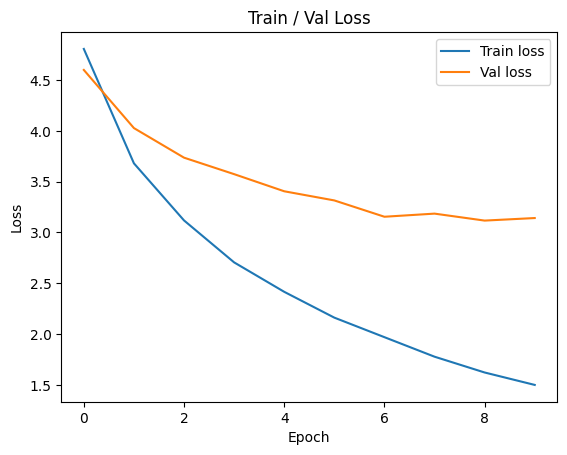

In [ ]:
plt.figure()
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Train / Val Loss')
plt.show()

## 12. Hàm `translate(sentence)` (greedy decoding)

In [ ]:
# Load best model (nếu cần, sau khi train xong)
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/best_model.pth', map_location=device))
model.eval()

def translate(sentence, max_len=20):
    # sentence: English string
    model.eval()
    with torch.no_grad():
        src_ids = sentence_to_ids_en(sentence).unsqueeze(0).to(device)  # (1, T)
        src_lengths = torch.tensor([src_ids.size(1)], dtype=torch.long).to(device)

        hidden, cell = model.encoder(src_ids, src_lengths)

        # Bắt đầu bằng <sos> bên target
        input_token = torch.tensor([fr_vocab.sos_index], dtype=torch.long, device=device)
        generated_ids = []

        for _ in range(max_len):
            logits, hidden, cell = model.decoder(input_token, hidden, cell)
            next_token_id = logits.argmax(1).item()

            if next_token_id == fr_vocab.eos_index:
                break
            generated_ids.append(next_token_id)
            input_token = torch.tensor([next_token_id], dtype=torch.long, device=device)

        # Convert ID -> token
        tokens = [fr_vocab.lookup_token(idx) for idx in generated_ids]
        return " ".join(tokens)


# Test nhanh với vài câu trong tập test
for i in range(3):
    print("EN :", test_en[i])
    print("REF:", test_fr[i])
    print("PRED:", translate(test_en[i]))
    print("---")

EN : A man in an orange hat starring at something.
REF: Un homme avec un chapeau orange regardant quelque chose.
PRED: un homme avec un chapeau orange quelque chose quelque chose .
---
EN : A Boston Terrier is running on lush green grass in front of a white fence.
REF: Un terrier de Boston court sur l'herbe verdoyante devant une clôture blanche.
PRED: un terrier terrier court court sur les herbe verte devant une clôture verte .
---
EN : A girl in karate uniform breaking a stick with a front kick.
REF: Une fille en tenue de karaté brisant un bâton avec un coup de pied.
PRED: une fille en tenue de karaté avec un coup de pied avec un panier en . .
---


## 13. Đánh giá BLEU trên tập test

In [ ]:
from nltk.translate.bleu_score import sentence_bleu

nltk.download('punkt')

def compute_bleu(num_samples=100):
    scores = []
    for i in range(min(num_samples, len(test_en))):
        pred = translate(test_en[i])
        ref_tokens = fr_tokenize(test_fr[i])
        pred_tokens = pred.split()

        if len(pred_tokens) == 0:
            scores.append(0)
            continue

        score = sentence_bleu([ref_tokens], pred_tokens, weights=(0.25,0.25,0.25,0.25))
        scores.append(score)
    return sum(scores)/len(scores)


bleu = compute_bleu(100)
print("Average BLEU (100 mẫu test):", bleu)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps 

Average BLEU (100 mẫu test): 0.34675336906342663


## 14. Gợi ý phân tích lỗi (in ra 5 ví dụ dịch sai)

In [ ]:
# In 5 ví dụ bất kỳ kèm so sánh và BLEU riêng
from nltk.translate.bleu_score import sentence_bleu

def show_error_examples(n=5):
    for i in range(n):
        idx = random.randint(0, len(test_en)-1)
        src = test_en[idx]
        ref = test_fr[idx]
        pred = translate(src)

        ref_tokens = fr_tokenize(ref)
        pred_tokens = pred.split()
        bleu = 0.0
        if len(pred_tokens) > 0:
            bleu = sentence_bleu([ref_tokens], pred_tokens, weights=(0.25,0.25,0.25,0.25))

        print(f"[Example {i+1}] BLEU={bleu:.4f}")
        print("EN  :", src)
        print("REF :", ref)
        print("PRED:", pred)
        print("-"*50)


show_error_examples(5)

[Example 1] BLEU=0.0000
EN  : A man from Uruguay is running through a park as part of a race or marathon.
REF : Une homme originaire d'Uruguay qui court un marathon ou pour une course à travers un parc.
PRED: un homme <unk> de courir dans un parc tandis qu' un d' un lors d' un marathon .
--------------------------------------------------
[Example 2] BLEU=1.0000
EN  : Two dogs running along the beach
REF : Deux chiens courant le long de la plage
PRED: deux chiens courant le long de la plage
--------------------------------------------------
[Example 3] BLEU=0.0000
EN  : Woman in blue swimsuit wet her hair in the river
REF : Une femme en maillot de bain bleu se mouille les cheveux dans la rivière.
PRED: une femme en tenue de bain bleu s' embrassant dans la plage
--------------------------------------------------
[Example 4] BLEU=0.0000
EN  : Some men are playing frisbee while one of them leaps into the air.
REF : Quelques hommes jouent au frisbee pendant qu'un d'entre eux saute dans les 

## 1) Luong Attention (global attention)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

In [19]:
# Attention kiểu Luong (global attention)
class LuongAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        # score(h_t, h_s) = v^T tanh(W [h_t; h_s])
        self.attn = nn.Linear(hid_dim * 2, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, decoder_hidden_last, encoder_outputs, src_mask):
        """
        decoder_hidden_last: (B, H)           - hidden cuối layer cuối của decoder
        encoder_outputs:      (B, src_len, H)
        src_mask:             (B, src_len) = 1 nếu token thật, 0 nếu pad
        """
        B, src_len, H = encoder_outputs.size()

        # Lặp hidden decoder ra src_len lần để concat với mỗi encoder state
        dec_hidden = decoder_hidden_last.unsqueeze(1).repeat(1, src_len, 1)  # (B,src_len,H)

        # concat [h_t ; h_s]
        energy = torch.cat((dec_hidden, encoder_outputs), dim=2)  # (B,src_len,2H)
        energy = torch.tanh(self.attn(energy))                    # (B,src_len,H)

        # v^T * energy -> (B,src_len,1) -> squeeze -> (B,src_len)
        scores = self.v(energy).squeeze(2)

        # Mask pad
        scores = scores.masked_fill(src_mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=1)                   # (B,src_len)

        # context = sum(alpha_i * h_i)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # (B,1,H)

        return context, attn_weights  # context: (B,1,H)

In [38]:
# Encoder trả về toàn bộ encoder_outputs để dùng cho attention
class EncoderWithOutputs(nn.Module):
    def __init__(self, vocab_size, pad_idx, emb_dim=512, hid_dim=512, num_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, src, src_lengths):
        """
        src:         (B, src_len)
        src_lengths: (B,)
        """
        embedded = self.embedding(src)  # (B,src_len,E)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_outputs, (hidden, cell) = self.lstm(packed)
        encoder_outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True)
        # encoder_outputs: (B, src_len, H)

        return encoder_outputs, hidden, cell


In [39]:
class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, pad_idx, emb_dim=512, hid_dim=512, num_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.attention = LuongAttention(hid_dim)

        # LSTM input: [embedded; context] -> E + H
        self.lstm = nn.LSTM(
            input_size=emb_dim + hid_dim,
            hidden_size=hid_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        # Output dựa trên [output; context]
        self.fc_out = nn.Linear(hid_dim + hid_dim, vocab_size)

    def forward(self, input_tokens, hidden, cell, encoder_outputs, src_mask):
        """
        input_tokens:   (B,)
        hidden, cell:   (num_layers, B, H)
        encoder_outputs:(B, src_len, H)
        src_mask:       (B, src_len)
        """
        embedded = self.embedding(input_tokens).unsqueeze(1)      # (B,1,E)

        # attention dùng hidden layer cuối cùng của decoder
        dec_last = hidden[-1]                                     # (B,H)
        context, attn_weights = self.attention(dec_last, encoder_outputs, src_mask)
        # context: (B,1,H)

        # LSTM input là concat(embedded, context)
        lstm_input = torch.cat((embedded, context), dim=2)        # (B,1,E+H)

        outputs, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))  # outputs: (B,1,H)

        # concat outputs + context để predict từ tiếp theo
        concat_out = torch.cat((outputs.squeeze(1), context.squeeze(1)), dim=1)  # (B,2H)
        logits = self.fc_out(concat_out)                           # (B,V)

        return logits, hidden, cell, attn_weights


In [40]:
def make_src_mask(src, pad_idx):
    """
    src: (B, src_len)
    trả về mask: (B, src_len) = 1 nếu không phải pad, 0 nếu pad
    """
    return (src != pad_idx).long()

In [41]:
class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx, tgt_pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.5):
        """
        src:         (B, src_len)
        src_lengths: (B,)
        tgt:         (B, tgt_len)
        """
        batch_size, tgt_len = tgt.size()
        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, tgt_len - 1, vocab_size, device=src.device)

        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)
        src_mask = make_src_mask(src, self.src_pad_idx)  # (B, src_len)

        input_token = tgt[:, 0]  # <sos>

        for t in range(1, tgt_len):
            logits, hidden, cell, _ = self.decoder(
                input_token, hidden, cell, encoder_outputs, src_mask
            )
            outputs[:, t - 1, :] = logits

            top1 = logits.argmax(1)
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if teacher_force else top1

        return outputs


## 2) Beam Search Decoding (ví dụ beam size = 3..5)

In [42]:
def translate_beam(sentence, beam_size=5, max_len=30, model_to_use=None,
                   src_sentence_to_ids=None, tgt_vocab=None):
    """
    Beam search decoding.

    - model_to_use:  mô hình Seq2Seq hoặc Seq2SeqWithAttention đã train.
    - src_sentence_to_ids: hàm chuyển câu EN -> tensor ids (BPE hoặc word-level).
    - tgt_vocab:    vocab target có .sos_index, .eos_index, .lookup_token().
    """
    assert model_to_use is not None
    assert src_sentence_to_ids is not None
    assert tgt_vocab is not None

    model_to_use.eval()
    with torch.no_grad():
        # Encode câu nguồn
        src_ids = src_sentence_to_ids(sentence).unsqueeze(0).to(device)  # (1, src_len)
        src_lengths = torch.tensor([src_ids.size(1)], dtype=torch.long).to(device)

        enc_out = model_to_use.encoder(src_ids, src_lengths)

        # Với model có attention: enc_out = (encoder_outputs, hidden, cell)
        encoder_outputs, hidden, cell = enc_out
        src_mask = make_src_mask(src_ids, model_to_use.src_pad_idx)

        # mỗi beam: (log_prob, sequence, hidden, cell)
        beams = [(0.0, [tgt_vocab.sos_index], hidden, cell, encoder_outputs, src_mask)]
        completed = []

        for _ in range(max_len):
            new_beams = []
            for log_prob, seq, h, c, enc_outs, m in beams:
                last_token = seq[-1]

                if last_token == tgt_vocab.eos_index:
                    completed.append((log_prob, seq))
                    continue

                input_token = torch.tensor([last_token], dtype=torch.long, device=device)

                logits, h_new, c_new, _ = model_to_use.decoder(
                    input_token, h, c, enc_outs, m
                )

                log_probs = F.log_softmax(logits, dim=-1).squeeze(0)  # (V,)
                topk_log_probs, topk_idx = torch.topk(log_probs, beam_size)

                for k in range(beam_size):
                    new_seq = seq + [topk_idx[k].item()]
                    new_lp = log_prob + topk_log_probs[k].item()
                    new_beams.append((new_lp, new_seq, h_new, c_new, enc_outs, m))

            if not new_beams:
                break

            # giữ lại beam_size beam tốt nhất
            new_beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]
            beams = new_beams

        if not completed:
            completed = [(lp, seq) for lp, seq, _, _, _, _ in beams]

        # Chọn câu có log_prob lớn nhất
        best_seq = max(completed, key=lambda x: x[0])[1]

        # Bỏ <sos>, dừng ở <eos>
        decoded_ids = []
        for idx in best_seq[1:]:
            if idx == tgt_vocab.eos_index:
                break
            decoded_ids.append(idx)

        tokens = [tgt_vocab.lookup_token(i) for i in decoded_ids]
        return " ".join(tokens)


## 3) Sử dụng Subword (BPE) bằng SentencePiece

---



In [25]:
!pip install -q sentencepiece

In [43]:
import sentencepiece as spm

# Ghi dữ liệu train ra file
with open("train_bpe_en.txt", "w", encoding="utf-8") as f:
    for line in train_en:
        f.write(line.lower().strip() + "\n")

with open("train_bpe_fr.txt", "w", encoding="utf-8") as f:
    for line in train_fr:
        f.write(line.lower().strip() + "\n")

# Train BPE cho EN và FR (ví dụ vocab_size = 8000)
spm.SentencePieceTrainer.train(
    input="train_bpe_en.txt",
    model_prefix="bpe_en",
    vocab_size=8000,
    model_type="bpe",
    character_coverage=1.0
)

spm.SentencePieceTrainer.train(
    input="train_bpe_fr.txt",
    model_prefix="bpe_fr",
    vocab_size=8000,
    model_type="bpe",
    character_coverage=1.0
)

In [44]:
sp_en = spm.SentencePieceProcessor(model_file="bpe_en.model")
sp_fr = spm.SentencePieceProcessor(model_file="bpe_fr.model")

def en_bpe_tokenize(text):
    return sp_en.encode(text.lower().strip(), out_type=str)

def fr_bpe_tokenize(text):
    return sp_fr.encode(text.lower().strip(), out_type=str)


In [45]:
# Dùng lại class Vocab trước đó
en_bpe_vocab = Vocab(train_en, en_bpe_tokenize, max_size=8000)
fr_bpe_vocab = Vocab(train_fr, fr_bpe_tokenize, max_size=8000)

print("EN BPE vocab size:", len(en_bpe_vocab))
print("FR BPE vocab size:", len(fr_bpe_vocab))


EN BPE vocab size: 7200
FR BPE vocab size: 7368


In [46]:
def sentence_to_ids_en_bpe(text):
    tokens = en_bpe_tokenize(text)
    ids = [en_bpe_vocab.sos_index] + [en_bpe_vocab[t] for t in tokens] + [en_bpe_vocab.eos_index]
    return torch.tensor(ids, dtype=torch.long)

def sentence_to_ids_fr_bpe(text):
    tokens = fr_bpe_tokenize(text)
    ids = [fr_bpe_vocab.sos_index] + [fr_bpe_vocab[t] for t in tokens] + [fr_bpe_vocab.eos_index]
    return torch.tensor(ids, dtype=torch.long)


In [47]:
def build_pairs_bpe(en_lines, fr_lines):
    pairs = []
    for en_line, fr_line in zip(en_lines, fr_lines):
        src_ids = sentence_to_ids_en_bpe(en_line)
        tgt_ids = sentence_to_ids_fr_bpe(fr_line)
        pairs.append((src_ids, tgt_ids))
    return pairs

train_pairs_bpe = build_pairs_bpe(train_en, train_fr)
val_pairs_bpe   = build_pairs_bpe(val_en, val_fr)
test_pairs_bpe  = build_pairs_bpe(test_en, test_fr)

print("Số cặp train BPE:", len(train_pairs_bpe))


Số cặp train BPE: 29000


In [48]:
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, pairs):
        """
        pairs: list of (src_ids, tgt_ids)
        mỗi phần tử là 2 tensor có shape: (seq_len,)
        """
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]


In [49]:
def collate_fn(batch):
    """
    batch: list of (src_tensor, tgt_tensor)
    """
    src_seqs = [item[0] for item in batch]
    tgt_seqs = [item[1] for item in batch]

    src_lengths = torch.tensor([len(s) for s in src_seqs], dtype=torch.long)
    tgt_lengths = torch.tensor([len(s) for s in tgt_seqs], dtype=torch.long)

    # Pad sequences
    src_padded = nn.utils.rnn.pad_sequence(src_seqs, batch_first=True, padding_value=en_bpe_vocab.pad_index)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_seqs, batch_first=True, padding_value=fr_bpe_vocab.pad_index)

    return src_padded, src_lengths, tgt_padded, tgt_lengths

In [50]:
# Dùng lại TranslationDataset, collate_fn của bạn
train_dataset_bpe = TranslationDataset(train_pairs_bpe)
val_dataset_bpe   = TranslationDataset(val_pairs_bpe)
test_dataset_bpe  = TranslationDataset(test_pairs_bpe)

train_loader_bpe = DataLoader(
    train_dataset_bpe,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader_bpe = DataLoader(
    val_dataset_bpe,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader_bpe = DataLoader(
    test_dataset_bpe,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)


## Train lại mô hình cải tiến (BPE + Attention)

In [51]:
# Khởi tạo model attention dùng vocab BPE
enc_bpe = EncoderWithOutputs(
    vocab_size=len(en_bpe_vocab),
    pad_idx=en_bpe_vocab.pad_index,
    emb_dim=512,
    hid_dim=512,
    num_layers=2,
    dropout=0.5
).to(device)

dec_bpe = AttnDecoder(
    vocab_size=len(fr_bpe_vocab),
    pad_idx=fr_bpe_vocab.pad_index,
    emb_dim=512,
    hid_dim=512,
    num_layers=2,
    dropout=0.5
).to(device)

model_att_bpe = Seq2SeqWithAttention(
    enc_bpe, dec_bpe,
    src_pad_idx=en_bpe_vocab.pad_index,
    tgt_pad_idx=fr_bpe_vocab.pad_index
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=fr_bpe_vocab.pad_index)
optimizer = torch.optim.Adam(model_att_bpe.parameters(), lr=1e-3)


In [52]:
def train_one_epoch(model, iterator, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0

    for src, src_lengths, tgt, tgt_lengths in iterator:
        src = src.to(device)
        src_lengths = src_lengths.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.5)
        # output: (B, tgt_len-1, V)
        output_dim = output.shape[-1]

        output = output.contiguous().view(-1, output_dim)  # (B*(tgt_len-1), V)
        tgt_y = tgt[:, 1:].contiguous().view(-1)           # (B*(tgt_len-1),)

        loss = criterion(output, tgt_y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)


def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, src_lengths, tgt, tgt_lengths in iterator:
            src = src.to(device)
            src_lengths = src_lengths.to(device)
            tgt = tgt.to(device)

            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]

            output = output.contiguous().view(-1, output_dim)
            tgt_y = tgt[:, 1:].contiguous().view(-1)

            loss = criterion(output, tgt_y)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [53]:
N_EPOCHS = 10
best_valid_loss = float('inf')

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(model_att_bpe, train_loader_bpe, optimizer, criterion)
    valid_loss = evaluate(model_att_bpe, val_loader_bpe, criterion)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model_att_bpe.state_dict(), "/content/drive/MyDrive/Colab Notebooks/model_att_bpe_best.pt")

    print(f"Epoch {epoch:02d}: "
          f"Train Loss = {train_loss:.3f}, "
          f"Valid Loss = {valid_loss:.3f}")

Epoch 01: Train Loss = 4.474, Valid Loss = 4.422
Epoch 02: Train Loss = 3.067, Valid Loss = 3.813
Epoch 03: Train Loss = 2.459, Valid Loss = 3.574
Epoch 04: Train Loss = 2.082, Valid Loss = 3.449
Epoch 05: Train Loss = 1.815, Valid Loss = 3.453
Epoch 06: Train Loss = 1.582, Valid Loss = 3.440
Epoch 07: Train Loss = 1.405, Valid Loss = 3.459
Epoch 08: Train Loss = 1.256, Valid Loss = 3.474
Epoch 09: Train Loss = 1.132, Valid Loss = 3.509
Epoch 10: Train Loss = 1.029, Valid Loss = 3.586


In [54]:
model_att_bpe.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/model_att_bpe_best.pt", map_location=device))
model_att_bpe.eval()

Seq2SeqWithAttention(
  (encoder): EncoderWithOutputs(
    (embedding): Embedding(7200, 512, padding_idx=1)
    (lstm): LSTM(512, 512, num_layers=2, batch_first=True, dropout=0.5)
  )
  (decoder): AttnDecoder(
    (embedding): Embedding(7368, 512, padding_idx=1)
    (attention): LuongAttention(
      (attn): Linear(in_features=1024, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (lstm): LSTM(1024, 512, num_layers=2, batch_first=True, dropout=0.5)
    (fc_out): Linear(in_features=1024, out_features=7368, bias=True)
  )
)

In [55]:
def translate_en2fr_bpe_beam(sent):
    return translate_beam(
        sentence=sent,
        beam_size=5,
        max_len=30,
        model_to_use=model_att_bpe,
        src_sentence_to_ids=sentence_to_ids_en_bpe,
        tgt_vocab=fr_bpe_vocab
    )

In [56]:
def translate_en2fr_bpe_greedy(sent, max_len=30):
    """
    Dịch EN -> FR bằng model_att_bpe với greedy decoding.
    """
    model_att_bpe.eval()
    with torch.no_grad():
        # Encode câu nguồn
        src_ids = sentence_to_ids_en_bpe(sent).unsqueeze(0).to(device)  # (1, src_len)
        src_lengths = torch.tensor([src_ids.size(1)], dtype=torch.long).to(device)

        encoder_outputs, hidden, cell = model_att_bpe.encoder(src_ids, src_lengths)
        src_mask = make_src_mask(src_ids, model_att_bpe.src_pad_idx)

        # Bắt đầu với <sos>
        input_token = torch.tensor([fr_bpe_vocab.sos_index], dtype=torch.long, device=device)

        decoded_ids = []

        for _ in range(max_len):
            logits, hidden, cell, _ = model_att_bpe.decoder(
                input_token, hidden, cell, encoder_outputs, src_mask
            )
            next_token = logits.argmax(dim=-1)  # (1,)
            next_id = next_token.item()

            if next_id == fr_bpe_vocab.eos_index:
                break

            decoded_ids.append(next_id)
            input_token = next_token  # dùng chính từ đã chọn làm input tiếp theo

        tokens = [fr_bpe_vocab.lookup_token(i) for i in decoded_ids]
        return " ".join(tokens)


In [57]:
# In một vài ví dụ từ tập test
num_examples = 5  # bạn muốn in bao nhiêu câu thì chỉnh số này

for i in range(num_examples):
    en_sent = test_en[i]
    fr_ref  = test_fr[i]

    # Baseline (word-level, greedy)
    try:
        fr_base_greedy = translate(en_sent)  # hàm baseline cũ của bạn
    except NameError:
        fr_base_greedy = "(chưa định nghĩa hàm translate baseline)"

    # BPE + Attention
    fr_bpe_greedy = translate_en2fr_bpe_greedy(en_sent)
    fr_bpe_beam   = translate_en2fr_bpe_beam(en_sent)

    print(f"===== Ví dụ {i+1} =====")
    print("EN     :", en_sent)
    print("REF FR :", fr_ref)
    print("BASE (word, greedy):      ", fr_base_greedy)
    print("BPE+ATT (greedy):         ", fr_bpe_greedy)
    print("BPE+ATT (beam=5):         ", fr_bpe_beam)
    print()


===== Ví dụ 1 =====
EN     : A man in an orange hat starring at something.
REF FR : Un homme avec un chapeau orange regardant quelque chose.
BASE (word, greedy):       (chưa định nghĩa hàm translate baseline)
BPE+ATT (greedy):          ▁un ▁homme ▁avec ▁une ▁casquette ▁orange ▁regarde ▁quelque ▁chose .
BPE+ATT (beam=5):          ▁un ▁homme ▁avec ▁une ▁casquette ▁orange ▁regarde ▁quelque ▁chose .

===== Ví dụ 2 =====
EN     : A Boston Terrier is running on lush green grass in front of a white fence.
REF FR : Un terrier de Boston court sur l'herbe verdoyante devant une clôture blanche.
BASE (word, greedy):       (chưa định nghĩa hàm translate baseline)
BPE+ATT (greedy):          ▁un ▁slal ome ▁court ▁sur ▁gazon ▁verte ▁vert ▁vert ▁devant ▁une ▁clôture ▁blanche .
BPE+ATT (beam=5):          ▁un ▁slal ome ▁court ▁sur ▁gazon ▁verte ▁court ▁devant ▁une ▁clôture ▁blanche .

===== Ví dụ 3 =====
EN     : A girl in karate uniform breaking a stick with a front kick.
REF FR : Une fille en tenue de 

In [58]:
!pip install -q nltk


In [59]:
import nltk
from nltk.translate.bleu_score import corpus_bleu


In [60]:
def compute_bleu(test_src, test_tgt, translate_fn, max_samples=None):
    """
    test_src: list câu EN
    test_tgt: list câu FR (ground truth)
    translate_fn: hàm nhận 1 câu EN -> câu FR dự đoán (string)
    max_samples: nếu muốn test trên một subset nhỏ cho nhanh, vd 500 câu
    """
    references = []
    hypotheses = []

    n = len(test_src)
    if max_samples is not None:
        n = min(n, max_samples)

    for i in range(n):
        src = test_src[i]
        ref = test_tgt[i]

        hyp = translate_fn(src)

        # Tokenize đơn giản bằng split
        ref_tokens = ref.strip().split()
        hyp_tokens = hyp.strip().split()

        # corpus_bleu cần: list of list-of-refs
        references.append([ref_tokens])
        hypotheses.append(hyp_tokens)

        if (i + 1) % 100 == 0:
            print(f"Đã dịch {i+1}/{n} câu...")

    bleu = corpus_bleu(references, hypotheses)
    return bleu


In [63]:
def translate(sentence, max_len=30):
    """
    Greedy decoding cho mô hình baseline word-level.
    """
    model.eval()
    with torch.no_grad():
        src_ids = sentence_to_ids_en(sentence).unsqueeze(0).to(device)
        src_lengths = torch.tensor([src_ids.size(1)], dtype=torch.long).to(device)

        hidden, cell = model.encoder(src_ids, src_lengths)

        input_token = torch.tensor([fr_vocab.sos_index], dtype=torch.long, device=device)
        decoded_ids = []

        for _ in range(max_len):
            logits, hidden, cell = model.decoder(input_token, hidden, cell)
            next_id = logits.argmax(-1).item()
            if next_id == fr_vocab.eos_index:
                break
            decoded_ids.append(next_id)
            input_token = torch.tensor([next_id], dtype=torch.long, device=device)

        tokens = [fr_vocab.lookup_token(i) for i in decoded_ids]
        return " ".join(tokens)

In [64]:
# 1. BLEU baseline (word-level, greedy)
def baseline_translate_fn(sent):
    return translate(sent)   # dùng hàm translate sẵn có

bleu_baseline = compute_bleu(test_en, test_fr, baseline_translate_fn, max_samples=None)
print("BLEU Baseline (word, greedy):", bleu_baseline)


Đã dịch 100/3532 câu...
Đã dịch 200/3532 câu...
Đã dịch 300/3532 câu...
Đã dịch 400/3532 câu...
Đã dịch 500/3532 câu...
Đã dịch 600/3532 câu...
Đã dịch 700/3532 câu...
Đã dịch 800/3532 câu...
Đã dịch 900/3532 câu...
Đã dịch 1000/3532 câu...
Đã dịch 1100/3532 câu...
Đã dịch 1200/3532 câu...
Đã dịch 1300/3532 câu...
Đã dịch 1400/3532 câu...
Đã dịch 1500/3532 câu...
Đã dịch 1600/3532 câu...
Đã dịch 1700/3532 câu...
Đã dịch 1800/3532 câu...
Đã dịch 1900/3532 câu...
Đã dịch 2000/3532 câu...
Đã dịch 2100/3532 câu...
Đã dịch 2200/3532 câu...
Đã dịch 2300/3532 câu...
Đã dịch 2400/3532 câu...
Đã dịch 2500/3532 câu...
Đã dịch 2600/3532 câu...
Đã dịch 2700/3532 câu...
Đã dịch 2800/3532 câu...
Đã dịch 2900/3532 câu...
Đã dịch 3000/3532 câu...
Đã dịch 3100/3532 câu...
Đã dịch 3200/3532 câu...
Đã dịch 3300/3532 câu...
Đã dịch 3400/3532 câu...
Đã dịch 3500/3532 câu...
BLEU Baseline (word, greedy): 3.0293125974099827e-232


In [62]:
# 2. BLEU BPE + Attention + Beam Search
def improved_translate_fn(sent):
    return translate_en2fr_bpe_beam(sent)

bleu_bpe_att_beam = compute_bleu(test_en, test_fr, improved_translate_fn, max_samples=None)
print("BLEU Improved (BPE+ATT, beam=5):", bleu_bpe_att_beam)
bleu_bpe_att_greedy = compute_bleu(test_en, test_fr, translate_en2fr_bpe_greedy, max_samples=None)
print("BLEU Improved (BPE+ATT, greedy):", bleu_bpe_att_greedy)


Đã dịch 100/3532 câu...
Đã dịch 200/3532 câu...
Đã dịch 300/3532 câu...
Đã dịch 400/3532 câu...
Đã dịch 500/3532 câu...
Đã dịch 600/3532 câu...
Đã dịch 700/3532 câu...
Đã dịch 800/3532 câu...
Đã dịch 900/3532 câu...
Đã dịch 1000/3532 câu...
Đã dịch 1100/3532 câu...
Đã dịch 1200/3532 câu...
Đã dịch 1300/3532 câu...
Đã dịch 1400/3532 câu...
Đã dịch 1500/3532 câu...
Đã dịch 1600/3532 câu...
Đã dịch 1700/3532 câu...
Đã dịch 1800/3532 câu...
Đã dịch 1900/3532 câu...
Đã dịch 2000/3532 câu...
Đã dịch 2100/3532 câu...
Đã dịch 2200/3532 câu...
Đã dịch 2300/3532 câu...
Đã dịch 2400/3532 câu...
Đã dịch 2500/3532 câu...
Đã dịch 2600/3532 câu...
Đã dịch 2700/3532 câu...
Đã dịch 2800/3532 câu...
Đã dịch 2900/3532 câu...
Đã dịch 3000/3532 câu...
Đã dịch 3100/3532 câu...
Đã dịch 3200/3532 câu...
Đã dịch 3300/3532 câu...
Đã dịch 3400/3532 câu...
Đã dịch 3500/3532 câu...


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

BLEU Improved (BPE+ATT, beam=5): 5.465875544607138e-232
Đã dịch 100/3532 câu...
Đã dịch 200/3532 câu...
Đã dịch 300/3532 câu...
Đã dịch 400/3532 câu...
Đã dịch 500/3532 câu...
Đã dịch 600/3532 câu...
Đã dịch 700/3532 câu...
Đã dịch 800/3532 câu...
Đã dịch 900/3532 câu...
Đã dịch 1000/3532 câu...
Đã dịch 1100/3532 câu...
Đã dịch 1200/3532 câu...
Đã dịch 1300/3532 câu...
Đã dịch 1400/3532 câu...
Đã dịch 1500/3532 câu...
Đã dịch 1600/3532 câu...
Đã dịch 1700/3532 câu...
Đã dịch 1800/3532 câu...
Đã dịch 1900/3532 câu...
Đã dịch 2000/3532 câu...
Đã dịch 2100/3532 câu...
Đã dịch 2200/3532 câu...
Đã dịch 2300/3532 câu...
Đã dịch 2400/3532 câu...
Đã dịch 2500/3532 câu...
Đã dịch 2600/3532 câu...
Đã dịch 2700/3532 câu...
Đã dịch 2800/3532 câu...
Đã dịch 2900/3532 câu...
Đã dịch 3000/3532 câu...
Đã dịch 3100/3532 câu...
Đã dịch 3200/3532 câu...
Đã dịch 3300/3532 câu...
Đã dịch 3400/3532 câu...
Đã dịch 3500/3532 câu...
BLEU Improved (BPE+ATT, greedy): 5.287899082745437e-232


In [65]:
import pandas as pd

rows = [
    ["Baseline (word, greedy)", bleu_baseline * 100],
]

# Nếu bạn có BLEU cho greedy BPE+ATT
try:
    rows.append(["BPE+ATT (greedy)", bleu_bpe_att_greedy * 100])
except NameError:
    pass

rows.append(["BPE+ATT (beam=5)", bleu_bpe_att_beam * 100])

df_bleu = pd.DataFrame(rows, columns=["Mô hình", "BLEU (test, %)"])
df_bleu


,Mô hình,"BLEU (test, %)"
0,"Baseline (word, greedy)",3.029313e-230
1,BPE+ATT (greedy),5.287899e-230
2,BPE+ATT (beam=5),5.465876e-230


from matplotlib import pyplot as plt
df_bleu['BLEU (test, %)'].plot(kind='hist', bins=20, title='BLEU (test, %)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
df_bleu.groupby('Mô hình').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['BLEU (test, %)']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'BLEU (test, %)'}, axis=1)
              .sort_values('BLEU (test, %)', ascending=True))
  xs = counted['BLEU (test, %)']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df_bleu.sort_values('BLEU (test, %)', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Mô hình')):
  _plot_series(series, series_name, i)
  fig.legend(title='Mô hình', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('BLEU (test, %)')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
df_bleu['BLEU (test, %)'].plot(kind='line', figsize=(8, 4), title='BLEU (test, %)')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df_bleu['Mô hình'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_bleu, x='BLEU (test, %)', y='Mô hình', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

## 10. Dùng dataset WMT 2014 (EN–FR)

Trong phần mở rộng, em dùng thêm một tập dữ liệu lớn hơn là WMT14 EN–FR (news commentary).
Để tránh quá nặng cho Colab, em chỉ lấy một subset vài trăm nghìn câu để huấn luyện thử nghiệm.


In [66]:
import os

wmt_dir = "/content/drive/MyDrive/Colab Notebooks/nlp_dataset/wmt14_enfr"
os.makedirs(wmt_dir, exist_ok=True)
%cd $wmt_dir

# Tải WMT14 news-commentary v9 song ngữ EN–FR
!wget -nc http://www.statmt.org/wmt14/training-parallel-nc-v9.tgz

# Giải nén
!tar -xvzf training-parallel-nc-v9.tgz

# Sau khi giải nén, ta có các file:
# training/news-commentary-v9.fr-en.en
# training/news-commentary-v9.fr-en.fr
print('-'*30)
!ls training

/content/drive/MyDrive/Colab Notebooks/nlp_dataset/wmt14_enfr
File ‘training-parallel-nc-v9.tgz’ already there; not retrieving.

training/
training/news-commentary-v9.fr-en.en
training/news-commentary-v9.ru-en.en
training/news-commentary-v9.ru-en.ru
training/news-commentary-v9.cs-en.cs
training/news-commentary-v9.de-en.en
training/news-commentary-v9.de-en.de
training/news-commentary-v9.cs-en.en
training/news-commentary-v9.fr-en.fr
------------------------------
news-commentary-v9.cs-en.cs  news-commentary-v9.fr-en.en
news-commentary-v9.cs-en.en  news-commentary-v9.fr-en.fr
news-commentary-v9.de-en.de  news-commentary-v9.ru-en.en
news-commentary-v9.de-en.en  news-commentary-v9.ru-en.ru


In [67]:
import itertools

en_path_wmt = os.path.join(wmt_dir, "training", "news-commentary-v9.fr-en.en")
fr_path_wmt = os.path.join(wmt_dir, "training", "news-commentary-v9.fr-en.fr")

def load_wmt_subset(en_path, fr_path, max_lines=200000, val_lines=5000, test_lines=5000):
    en_lines = []
    fr_lines = []

    with open(en_path, encoding="utf8") as f_en, open(fr_path, encoding="utf8") as f_fr:
        for i, (en_line, fr_line) in enumerate(zip(f_en, f_fr)):
            if i >= max_lines + val_lines + test_lines:
                break
            en_lines.append(en_line.strip())
            fr_lines.append(fr_line.strip())

    # chia: [0 : max_lines] -> train
    #      [max_lines : max_lines+val_lines] -> val
    #      [max_lines+val_lines : ...] -> test
    train_en_wmt = en_lines[:max_lines]
    train_fr_wmt = fr_lines[:max_lines]

    val_en_wmt   = en_lines[max_lines:max_lines+val_lines]
    val_fr_wmt   = fr_lines[max_lines:max_lines+val_lines]

    test_en_wmt  = en_lines[max_lines+val_lines:max_lines+val_lines+test_lines]
    test_fr_wmt  = fr_lines[max_lines+val_lines:max_lines+val_lines+test_lines]

    return train_en_wmt, train_fr_wmt, val_en_wmt, val_fr_wmt, test_en_wmt, test_fr_wmt

# lấy subset: 200k train, 5k val, 5k test (con số này bạn có thể giảm nếu quá nặng)
train_en_wmt, train_fr_wmt, val_en_wmt, val_fr_wmt, test_en_wmt, test_fr_wmt = load_wmt_subset(
    en_path_wmt, fr_path_wmt,
    max_lines=200000,
    val_lines=5000,
    test_lines=5000
)

print("WMT14 train:", len(train_en_wmt))
print("WMT14 val  :", len(val_en_wmt))
print("WMT14 test :", len(test_en_wmt))
print("Ví dụ EN:", train_en_wmt[0])
print("Ví dụ FR:", train_fr_wmt[0])

WMT14 train: 183756
WMT14 val  : 0
WMT14 test : 0
Ví dụ EN: $10,000 Gold?
Ví dụ FR: L’or à 10.000 dollars l’once ?


In [ ]:
# Dùng lại class Vocab đã định nghĩa trước đó
# Nếu chưa có, bạn copy class Vocab từ phần Multi30K lên trên.
SPECIAL_TOKENS = ['<unk>', '<pad>', '<sos>', '<eos>']

class Vocab:
    def __init__(self, texts, tokenizer, max_size=20000, specials=SPECIAL_TOKENS):
        counter = Counter()
        for line in texts:
            counter.update(tokenizer(line))

        self.itos = list(specials)
        for tok, _ in counter.most_common(max_size - len(self.itos)):
            if tok not in self.itos:
                self.itos.append(tok)

        self.stoi = {tok: idx for idx, tok in enumerate(self.itos)}

        # Đảm bảo các token đặc biệt tồn tại
        for sp in specials:
            if sp not in self.stoi:
                self.stoi[sp] = len(self.itos)
                self.itos.append(sp)

        self.unk_index = self.stoi['<unk>']
        self.pad_index = self.stoi['<pad>']
        self.sos_index = self.stoi['<sos>']
        self.eos_index = self.stoi['<eos>']

    def __len__(self):
        return len(self.itos)

    def __getitem__(self, token):
        return self.stoi.get(token, self.unk_index)

    def lookup_token(self, idx):
        return self.itos[idx]

    def get_stoi(self):
        return self.stoi


# Xây vocab cho EN / FR từ tập train
wmt_en_vocab = Vocab(train_en_wmt, en_tokenize, max_size=20000)  # vocab to hơn tí
wmt_fr_vocab = Vocab(train_fr_wmt, fr_tokenize, max_size=20000)

print("WMT EN vocab size:", len(wmt_en_vocab))
print("WMT FR vocab size:", len(wmt_fr_vocab))


In [ ]:
def wmt_sentence_to_ids_en(text):
    tokens = en_tokenize(text)
    ids = [wmt_en_vocab.sos_index] + [wmt_en_vocab[t] for t in tokens] + [wmt_en_vocab.eos_index]
    return torch.tensor(ids, dtype=torch.long)

def wmt_sentence_to_ids_fr(text):
    tokens = fr_tokenize(text)
    ids = [wmt_fr_vocab.sos_index] + [wmt_fr_vocab[t] for t in tokens] + [wmt_fr_vocab.eos_index]
    return torch.tensor(ids, dtype=torch.long)

def build_wmt_pairs(en_lines, fr_lines):
    pairs = []
    for en_line, fr_line in zip(en_lines, fr_lines):
        src_ids = wmt_sentence_to_ids_en(en_line)
        tgt_ids = wmt_sentence_to_ids_fr(fr_line)
        pairs.append((src_ids, tgt_ids))
    return pairs

wmt_train_pairs = build_wmt_pairs(train_en_wmt, train_fr_wmt)
wmt_val_pairs   = build_wmt_pairs(val_en_wmt,   val_fr_wmt)
wmt_test_pairs  = build_wmt_pairs(test_en_wmt,  test_fr_wmt)

print("Số cặp WMT train:", len(wmt_train_pairs))
print("Ví dụ tensor EN:", wmt_train_pairs[0][0][:10])
print("Ví dụ tensor FR:", wmt_train_pairs[0][1][:10])

In [ ]:
MAX_LEN_WMT = 40

def filter_pairs(pairs, max_len=MAX_LEN_WMT):
    return [(s, t) for (s, t) in pairs if len(s) <= max_len and len(t) <= max_len]

wmt_train_pairs = filter_pairs(wmt_train_pairs)
wmt_val_pairs   = filter_pairs(wmt_val_pairs)
wmt_test_pairs  = filter_pairs(wmt_test_pairs)

print("Sau khi lọc độ dài:")
print("WMT train:", len(wmt_train_pairs))
print("WMT val  :", len(wmt_val_pairs))
print("WMT test :", len(wmt_test_pairs))


In [ ]:
def wmt_collate_fn(batch):
    src_list, tgt_list = zip(*batch)
    src_lengths = [len(s) for s in src_list]

    sorted_idx = sorted(range(len(src_lengths)), key=lambda i: -src_lengths[i])
    src_list = [src_list[i] for i in sorted_idx]
    tgt_list = [tgt_list[i] for i in sorted_idx]
    src_lengths = [len(s) for s in src_list]

    src_padded = pad_sequence(src_list, batch_first=True, padding_value=wmt_en_vocab.pad_index)
    tgt_padded = pad_sequence(tgt_list, batch_first=True, padding_value=wmt_fr_vocab.pad_index)

    return src_padded, torch.tensor(src_lengths, dtype=torch.long), tgt_padded

wmt_batch_size = 64

wmt_train_loader = DataLoader(wmt_train_pairs, batch_size=wmt_batch_size,
                              shuffle=True, collate_fn=wmt_collate_fn)
wmt_val_loader   = DataLoader(wmt_val_pairs, batch_size=wmt_batch_size,
                              shuffle=False, collate_fn=wmt_collate_fn)

In [ ]:
# Model dành cho WMT14
wmt_enc = Encoder(vocab_size=len(wmt_en_vocab), emb_dim=512, hid_dim=512, num_layers=2, dropout=0.5).to(device)
wmt_dec = Decoder(vocab_size=len(wmt_fr_vocab), emb_dim=512, hid_dim=512, num_layers=2, dropout=0.5).to(device)
wmt_model = Seq2Seq(wmt_enc, wmt_dec, tgt_pad_idx=wmt_fr_vocab.pad_index).to(device)

wmt_criterion = nn.CrossEntropyLoss(ignore_index=wmt_fr_vocab.pad_index)
wmt_optimizer = optim.Adam(wmt_model.parameters(), lr=0.001, weight_decay=1e-5)

print(wmt_model)

In [ ]:
WMT_EPOCHS = 5

wmt_train_losses = []
wmt_val_losses = []

for epoch in range(1, WMT_EPOCHS+1):
    wmt_model.train()
    total_train_loss = 0.0

    for src, src_lengths, tgt in wmt_train_loader:
        src, src_lengths, tgt = src.to(device), src_lengths.to(device), tgt.to(device)

        wmt_optimizer.zero_grad()
        output = wmt_model(src, src_lengths, tgt, teacher_forcing_ratio=0.5)
        B, Tm1, V = output.size()
        loss = wmt_criterion(output.reshape(B*Tm1, V), tgt[:,1:].reshape(-1))
        loss.backward()
        wmt_optimizer.step()
        total_train_loss += loss.item()

    avg_train = total_train_loss / len(wmt_train_loader)
    wmt_train_losses.append(avg_train)

    # validation
    wmt_model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for src, src_lengths, tgt in wmt_val_loader:
            src, src_lengths, tgt = src.to(device), src_lengths.to(device), tgt.to(device)
            output = wmt_model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)
            B, Tm1, V = output.size()
            loss = wmt_criterion(output.reshape(B*Tm1, V), tgt[:,1:].reshape(-1))
            total_val_loss += loss.item()

    avg_val = total_val_loss / len(wmt_val_loader)
    wmt_val_losses.append(avg_val)

    print(f"[WMT] Epoch {epoch}: train_loss={avg_train:.4f} | val_loss={avg_val:.4f}")

In [ ]:
plt.figure()
plt.plot(wmt_train_losses, label="WMT train")
plt.plot(wmt_val_losses, label="WMT val")
plt.title("WMT14 EN–FR - Train/Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
def translate_wmt(sentence, max_len=50):
    wmt_model.eval()
    with torch.no_grad():
        src_ids = wmt_sentence_to_ids_en(sentence).unsqueeze(0).to(device)
        src_lengths = torch.tensor([src_ids.size(1)], dtype=torch.long).to(device)

        hidden, cell = wmt_model.encoder(src_ids, src_lengths)
        input_token = torch.tensor([wmt_fr_vocab.sos_index], dtype=torch.long, device=device)

        generated = []
        for _ in range(max_len):
            logits, hidden, cell = wmt_model.decoder(input_token, hidden, cell)
            next_id = logits.argmax(1).item()
            if next_id == wmt_fr_vocab.eos_index:
                break
            generated.append(next_id)
            input_token = torch.tensor([next_id], dtype=torch.long, device=device)

        tokens = [wmt_fr_vocab.lookup_token(i) for i in generated]
        return " ".join(tokens)

# test nhanh 3 câu
for i in range(3):
    print("EN :", test_en_wmt[i])
    print("REF:", test_fr_wmt[i])
    print("PRED:", translate_wmt(test_en_wmt[i]))
    print("---")


In [ ]:
from nltk.translate.bleu_score import sentence_bleu

def compute_wmt_bleu(num_samples=100):
    scores = []
    for i in range(min(num_samples, len(test_en_wmt))):
        src = test_en_wmt[i]
        ref = test_fr_wmt[i]
        pred = translate_wmt(src)

        ref_tokens = fr_tokenize(ref)
        pred_tokens = pred.split()

        if len(pred_tokens) == 0:
            scores.append(0.0)
            continue

        score = sentence_bleu([ref_tokens], pred_tokens,
                              weights=(0.25,0.25,0.25,0.25))
        scores.append(score)
    return sum(scores)/len(scores)

print("WMT BLEU (subset 100 câu):", compute_wmt_bleu(100))